# 28 — Assembly101 residual pseudo-text logit fusion

**Goal.** Test whether inference-time Qwen pseudo-text can improve the strong visual-only MS-TCN without allowing the weak pseudo-text teacher to replace the visual prediction.

The method uses the visual-only model from notebook 16 as the anchor and adds only the text-induced teacher residual

\[
\log p_{\text{fused}}
= \log p_{\text{visual}}
+ \alpha\,g(x)\,\operatorname{clip}\!\left(
\log p_{\text{teacher}}(y\mid v,t)
- \log p_{\text{teacher}}(y\mid v,0)
\right).
\]

The residual is restricted to the visual model's top-*k* classes. The gate can require low teacher entropy, visual uncertainty, and agreement with the visual shortlist. Setting `alpha = 0` exactly recovers the visual-only model.

This is a **validation-only** experiment. No test bundle, test labels, or test predictions are read.


## Protocol

1. Reproduce notebook 16's full validation metrics from its frozen checkpoint.
2. Split the 120 validation sequences deterministically into 60 calibration and 60 holdout sequences using sequence IDs only.
3. Select fusion hyperparameters on calibration F1@50, with Edit as a tie-breaker.
4. Evaluate the single frozen configuration once on holdout and on the full validation set.
5. Recommend a test run only when calibration, holdout, and full-validation F1@50 each improve by at least 0.30 points and the Edit drop is at most 1.0 point.

The caption embeddings come directly from notebook 26; Qwen is not rerun.


In [9]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


In [10]:
from pathlib import Path
from datetime import datetime, timezone
import gc
import hashlib
import json
import math
import platform
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 220)

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if not torch.cuda.is_available():
    raise RuntimeError("Select a GPU runtime before running notebook 28.")

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.13
PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [11]:
DRIVE_ROOT = Path("/content/drive/MyDrive/mmf_tas_lab_data")
FEATURE_ROOT = (
    DRIVE_ROOT / "text_assisted_tas" / "assembly101"
    / "coarse_mstcn_format" / "streaming_visual_features_v1"
)
CLIP_DATA_ROOT = FEATURE_ROOT / "clip_vitb16"
FEATURE_DIR = CLIP_DATA_ROOT / "features"
GT_DIR = CLIP_DATA_ROOT / "groundTruth"
SPLIT_DIR = CLIP_DATA_ROOT / "splits"
MAPPING_PATH = CLIP_DATA_ROOT / "mapping.txt"

# Notebook 16: strong visual-only anchor.
VISUAL_ROOT = FEATURE_ROOT / "runs" / "16_visual_only_mstcn" / "clip_vitb16" / "full"
VISUAL_CHECKPOINT = VISUAL_ROOT / "models" / "best_model.pt"
VISUAL_SUMMARY = VISUAL_ROOT / "results" / "final_summary.json"
VISUAL_MEAN_PATH = VISUAL_ROOT / "results" / "train_feature_mean.npy"
VISUAL_STD_PATH = VISUAL_ROOT / "results" / "train_feature_std.npy"

# Notebook 18: privileged-text teacher.
TEACHER_ROOT = FEATURE_ROOT / "runs" / "18_text_assisted_concat_teachers" / "mstcn" / "clip_vitb16" / "full"
TEACHER_CHECKPOINT = TEACHER_ROOT / "models" / "best_teacher.pt"
TEACHER_MEAN_PATH = TEACHER_ROOT / "results" / "train_video_mean.npy"
TEACHER_STD_PATH = TEACHER_ROOT / "results" / "train_video_std.npy"

# Notebook 26: fixed caption embeddings generated without ground truth.
NOTEBOOK26_ROOT = FEATURE_ROOT / "runs" / "26_qwen_caption_embedding_ablation"
NOTEBOOK26_SUMMARY = NOTEBOOK26_ROOT / "final_summary.json"
CAPTION_INPUT_ROOT = NOTEBOOK26_ROOT / "caption_text_inputs"
CAPTION_VARIANTS = [
    "caption_direct",
    "caption_prompted",
    "caption_top1",
    "caption_soft_top5",
    "caption_soft_top5_temporal",
]

OUT_ROOT = FEATURE_ROOT / "runs" / "28_residual_pseudotext_logit_fusion"
PREDICTION_ROOT = OUT_ROOT / "selected_predictions_validation"
ARTIFACT_ROOT = OUT_ROOT / "presentation_artifacts"
for path in [OUT_ROOT, PREDICTION_ROOT, ARTIFACT_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

EXPECTED_VIDEO_DIM = 512
EXPECTED_TEXT_DIM = 512
EXPECTED_TEMPORAL_LENGTH = 16
EXPECTED_NUM_CLASSES = 202
BATCH_SIZE = 64
NUM_WORKERS = 0

# Conservative search space. alpha=0 is evaluated separately as the exact baseline.
ALPHAS = [0.05, 0.10, 0.20, 0.40]
VISUAL_TOP_KS = [3, 5, 10]
RESIDUAL_CLIPS = [0.50, 1.00]
CAPTION_CONFIDENCE_QUANTILES = [0.25, 0.50, 1.00]
VISUAL_UNCERTAINTY_QUANTILES = [0.50, 0.75, 1.00]

BASELINE_REPRO_TOLERANCE = 0.02
MIN_REQUIRED_F1_50_GAIN = 0.30
MAX_ALLOWED_EDIT_DROP = 1.00
NEAR_BEST_CALIBRATION_F1 = 0.05
FORCE_RECOMPUTE_LOGITS = False
LOGIT_CACHE = OUT_ROOT / "validation_logits_cache.npz"

print("Output root:", OUT_ROOT)
print("Caption variants:", CAPTION_VARIANTS)


Output root: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/28_residual_pseudotext_logit_fusion
Caption variants: ['caption_direct', 'caption_prompted', 'caption_top1', 'caption_soft_top5', 'caption_soft_top5_temporal']


In [12]:
def read_nonempty_lines(path):
    return [
        line.strip()
        for line in Path(path).read_text(encoding="utf-8", errors="replace").splitlines()
        if line.strip()
    ]


def load_mapping(path):
    id_to_label = {}
    label_to_id = {}
    for line in read_nonempty_lines(path):
        index_text, label = line.split(maxsplit=1)
        index = int(index_text)
        if index in id_to_label or label in label_to_id:
            raise ValueError(f"Duplicate mapping entry: {line}")
        id_to_label[index] = label
        label_to_id[label] = index
    return id_to_label, label_to_id


def resolve_validation_bundle(split_dir):
    exact = [Path(split_dir) / "val.bundle", Path(split_dir) / "val.split1.bundle"]
    for candidate in exact:
        if candidate.exists():
            return candidate
    candidates = sorted(
        path for path in Path(split_dir).glob("*.bundle")
        if "val" in path.name.lower() and ".partial." not in path.name.lower()
    )
    if len(candidates) != 1:
        raise FileNotFoundError(f"Could not uniquely resolve validation bundle: {candidates}")
    return candidates[0]


required_paths = {
    "features": FEATURE_DIR,
    "validation ground truth": GT_DIR,
    "mapping": MAPPING_PATH,
    "visual checkpoint": VISUAL_CHECKPOINT,
    "visual summary": VISUAL_SUMMARY,
    "visual mean": VISUAL_MEAN_PATH,
    "visual std": VISUAL_STD_PATH,
    "teacher checkpoint": TEACHER_CHECKPOINT,
    "teacher mean": TEACHER_MEAN_PATH,
    "teacher std": TEACHER_STD_PATH,
    "notebook 26 summary": NOTEBOOK26_SUMMARY,
}
for variant in CAPTION_VARIANTS:
    required_paths[f"notebook 26 embeddings: {variant}"] = CAPTION_INPUT_ROOT / variant

for name, path in required_paths.items():
    exists = Path(path).exists()
    print(f"{name}: {path} -> exists={exists}")
    if not exists:
        raise FileNotFoundError(f"Missing prerequisite: {name}: {path}")

id_to_label, label_to_id = load_mapping(MAPPING_PATH)
num_classes = len(id_to_label)
VAL_BUNDLE = resolve_validation_bundle(SPLIT_DIR)
val_ids = [Path(line).stem for line in read_nonempty_lines(VAL_BUNDLE)]

if num_classes != EXPECTED_NUM_CLASSES:
    raise ValueError(f"Expected 202 classes, got {num_classes}.")
if set(id_to_label) != set(range(num_classes)):
    raise ValueError("Mapping IDs must be contiguous 0..201.")
if len(val_ids) != 120 or len(set(val_ids)) != 120:
    raise ValueError(f"Expected 120 unique validation sequences, got {len(val_ids)}.")

visual_summary = json.loads(VISUAL_SUMMARY.read_text(encoding="utf-8"))
notebook26_summary = json.loads(NOTEBOOK26_SUMMARY.read_text(encoding="utf-8"))
if visual_summary.get("status") != "completed":
    raise RuntimeError("Notebook 16 visual experiment is not completed.")
if visual_summary.get("representation") != "clip_vitb16":
    raise RuntimeError("Notebook 16 summary is not the CLIP visual baseline.")
if notebook26_summary.get("status") != "completed":
    raise RuntimeError("Notebook 26 is not completed.")
if notebook26_summary.get("data", {}).get("split") != "validation":
    raise RuntimeError("Notebook 26 is not a validation-only result.")
if notebook26_summary.get("data", {}).get("test_accessed") is not False:
    raise RuntimeError("Notebook 26 reports that test data was accessed.")

for variant in CAPTION_VARIANTS:
    observed = {path.stem for path in (CAPTION_INPUT_ROOT / variant).glob("*.npy")}
    if observed != set(val_ids):
        raise RuntimeError(
            f"Caption embedding cohort mismatch for {variant}: "
            f"missing={sorted(set(val_ids) - observed)[:5]}, extra={sorted(observed - set(val_ids))[:5]}"
        )

visual_mean = np.load(VISUAL_MEAN_PATH).astype(np.float32)
visual_std = np.load(VISUAL_STD_PATH).astype(np.float32)
teacher_mean = np.load(TEACHER_MEAN_PATH).astype(np.float32)
teacher_std = np.load(TEACHER_STD_PATH).astype(np.float32)
for name, array in {
    "visual mean": visual_mean,
    "visual std": visual_std,
    "teacher mean": teacher_mean,
    "teacher std": teacher_std,
}.items():
    if array.shape != (EXPECTED_VIDEO_DIM,) or not np.isfinite(array).all():
        raise ValueError(f"Invalid {name}: shape={array.shape}")

print("Validation sequences:", len(val_ids))
print("Classes:", num_classes)
print("Notebook 26 Qwen model:", notebook26_summary.get("source", {}).get("qwen_model_id"))
print("Test accessed: False")


features: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/features -> exists=True
validation ground truth: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/groundTruth -> exists=True
mapping: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/mapping.txt -> exists=True
visual checkpoint: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/16_visual_only_mstcn/clip_vitb16/full/models/best_model.pt -> exists=True
visual summary: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/16_visual_only_mstcn/clip_vitb16/full/results/final_summary.json -> exists=True
visual mean: /content/drive/MyDrive/mmf_tas_lab_

In [13]:
class FusionValidationDataset(Dataset):
    def __init__(self, sequence_ids, text_mode):
        self.sequence_ids = list(sequence_ids)
        self.text_mode = str(text_mode)
        if self.text_mode not in {"zero_text", *CAPTION_VARIANTS}:
            raise ValueError(f"Unknown text mode: {self.text_mode}")

    def __len__(self):
        return len(self.sequence_ids)

    def __getitem__(self, index):
        sequence_id = self.sequence_ids[index]
        raw_video = np.load(FEATURE_DIR / f"{sequence_id}.npy").astype(np.float32)
        label_names = read_nonempty_lines(GT_DIR / f"{sequence_id}.txt")
        labels = np.asarray([label_to_id[label] for label in label_names], dtype=np.int64)

        if raw_video.shape != (EXPECTED_VIDEO_DIM, EXPECTED_TEMPORAL_LENGTH):
            raise ValueError(f"Unexpected feature shape for {sequence_id}: {raw_video.shape}")
        if labels.shape != (EXPECTED_TEMPORAL_LENGTH,):
            raise ValueError(f"Unexpected label shape for {sequence_id}: {labels.shape}")

        visual_video = (raw_video - visual_mean[:, None]) / (visual_std[:, None] + 1e-8)
        teacher_video = (raw_video - teacher_mean[:, None]) / (teacher_std[:, None] + 1e-8)

        if self.text_mode == "zero_text":
            text = np.zeros((EXPECTED_TEXT_DIM, EXPECTED_TEMPORAL_LENGTH), dtype=np.float32)
        else:
            text = np.load(
                CAPTION_INPUT_ROOT / self.text_mode / f"{sequence_id}.npy"
            ).astype(np.float32)
        if text.shape != (EXPECTED_TEXT_DIM, EXPECTED_TEMPORAL_LENGTH):
            raise ValueError(f"Unexpected text shape for {sequence_id}: {text.shape}")

        return {
            "sequence_id": sequence_id,
            "visual_video": torch.from_numpy(visual_video.astype(np.float32)),
            "teacher_video": torch.from_numpy(teacher_video.astype(np.float32)),
            "teacher_text": torch.from_numpy(text),
            "labels": torch.from_numpy(labels),
        }


sample = FusionValidationDataset(val_ids[:1], CAPTION_VARIANTS[0])[0]
assert tuple(sample["visual_video"].shape) == (512, 16)
assert tuple(sample["teacher_video"].shape) == (512, 16)
assert tuple(sample["teacher_text"].shape) == (512, 16)
assert tuple(sample["labels"].shape) == (16,)
print("Dataset smoke test passed.")


Dataset smoke test passed.


In [14]:
class VisualDilatedResidualLayer(nn.Module):
    def __init__(self, dilation, channels, dropout):
        super().__init__()
        self.conv_dilated = nn.Conv1d(
            channels, channels, kernel_size=3, padding=dilation, dilation=dilation
        )
        self.conv_1x1 = nn.Conv1d(channels, channels, kernel_size=1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x = F.relu(self.conv_dilated(x))
        x = self.conv_1x1(x)
        x = self.dropout(x)
        return residual + x


class VisualSingleStageModel(nn.Module):
    def __init__(self, num_layers, num_f_maps, input_dim, num_classes, dropout):
        super().__init__()
        self.conv_in = nn.Conv1d(input_dim, num_f_maps, kernel_size=1)
        self.layers = nn.ModuleList([
            VisualDilatedResidualLayer(2 ** layer_index, num_f_maps, dropout)
            for layer_index in range(num_layers)
        ])
        self.conv_out = nn.Conv1d(num_f_maps, num_classes, kernel_size=1)

    def forward(self, x):
        x = self.conv_in(x)
        for layer in self.layers:
            x = layer(x)
        return self.conv_out(x)


class VisualMultiStageModel(nn.Module):
    def __init__(self, num_stages, num_layers, num_f_maps, input_dim, num_classes, dropout):
        super().__init__()
        self.stage1 = VisualSingleStageModel(
            num_layers, num_f_maps, input_dim, num_classes, dropout
        )
        self.stages = nn.ModuleList([
            VisualSingleStageModel(num_layers, num_f_maps, num_classes, num_classes, dropout)
            for _ in range(num_stages - 1)
        ])

    def forward(self, x):
        outputs = [self.stage1(x)]
        for stage in self.stages:
            outputs.append(stage(F.softmax(outputs[-1], dim=1)))
        return torch.stack(outputs, dim=0)


class TeacherDilatedResidualLayer(nn.Module):
    def __init__(self, dilation, channels, dropout):
        super().__init__()
        self.conv_dilated = nn.Conv1d(
            channels, channels, kernel_size=3, padding=dilation, dilation=dilation
        )
        self.conv_1x1 = nn.Conv1d(channels, channels, kernel_size=1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x = F.relu(self.conv_dilated(x))
        x = self.conv_1x1(x)
        x = self.dropout(x)
        return residual + x


class TeacherSingleStage(nn.Module):
    def __init__(self, input_dim, num_classes, num_layers, num_f_maps, dropout):
        super().__init__()
        self.input_projection = nn.Conv1d(input_dim, num_f_maps, kernel_size=1)
        self.layers = nn.ModuleList([
            TeacherDilatedResidualLayer(2 ** layer_index, num_f_maps, dropout)
            for layer_index in range(num_layers)
        ])
        self.output_projection = nn.Conv1d(num_f_maps, num_classes, kernel_size=1)

    def forward(self, x):
        x = self.input_projection(x)
        for layer in self.layers:
            x = layer(x)
        return self.output_projection(x)


class PrivilegedTextTeacher(nn.Module):
    def __init__(self, num_classes, num_stages=4, num_layers=6, num_f_maps=64, dropout=0.5):
        super().__init__()
        self.stage1 = TeacherSingleStage(
            EXPECTED_VIDEO_DIM + EXPECTED_TEXT_DIM,
            num_classes,
            num_layers,
            num_f_maps,
            dropout,
        )
        self.refinement_stages = nn.ModuleList([
            TeacherSingleStage(num_classes, num_classes, num_layers, num_f_maps, dropout)
            for _ in range(num_stages - 1)
        ])

    def forward(self, video, text):
        outputs = [self.stage1(torch.cat([video, text], dim=1))]
        for stage in self.refinement_stages:
            outputs.append(stage(F.softmax(outputs[-1], dim=1)))
        return torch.stack(outputs, dim=0)


def torch_load_checkpoint(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


visual_checkpoint = torch_load_checkpoint(VISUAL_CHECKPOINT)
visual_config = visual_checkpoint.get("model_config", {})
visual_model = VisualMultiStageModel(
    num_stages=int(visual_config.get("num_stages", 4)),
    num_layers=int(visual_config.get("num_layers", 6)),
    num_f_maps=int(visual_config.get("num_f_maps", 64)),
    input_dim=int(visual_config.get("input_dim", EXPECTED_VIDEO_DIM)),
    num_classes=int(visual_config.get("num_classes", num_classes)),
    dropout=float(visual_config.get("dropout", 0.5)),
).to(DEVICE)
visual_model.load_state_dict(visual_checkpoint["model_state_dict"], strict=True)
visual_model.eval()

teacher_checkpoint = torch_load_checkpoint(TEACHER_CHECKPOINT)
if teacher_checkpoint.get("temporal_model") != "mstcn":
    raise RuntimeError("Unexpected teacher temporal model.")
if teacher_checkpoint.get("representation") != "clip_vitb16":
    raise RuntimeError("Unexpected teacher representation.")
if teacher_checkpoint.get("teacher_type") != "privileged_concat":
    raise RuntimeError("Unexpected teacher type.")
teacher_model = PrivilegedTextTeacher(num_classes=num_classes).to(DEVICE)
teacher_model.load_state_dict(teacher_checkpoint["model_state_dict"], strict=True)
teacher_model.eval()

with torch.no_grad():
    visual_smoke = visual_model(torch.zeros(2, 512, 16, device=DEVICE))
    teacher_smoke = teacher_model(
        torch.zeros(2, 512, 16, device=DEVICE),
        torch.zeros(2, 512, 16, device=DEVICE),
    )
assert tuple(visual_smoke.shape) == (4, 2, num_classes, 16)
assert tuple(teacher_smoke.shape) == (4, 2, num_classes, 16)
print("Visual checkpoint epoch:", visual_checkpoint.get("epoch"))
print("Teacher checkpoint epoch:", teacher_checkpoint.get("epoch"))
print("Model smoke tests passed.")


Visual checkpoint epoch: 110
Teacher checkpoint epoch: 120
Model smoke tests passed.


In [15]:
CANDIDATE_IGNORE_CLASSES = {"background", "SIL", "silence"}
ignore_class_ids = {
    label_to_id[label] for label in CANDIDATE_IGNORE_CLASSES if label in label_to_id
}


def collapse_segments(frame_labels, ignored_ids=None):
    ignored_ids = set(ignored_ids or [])
    labels, starts, ends = [], [], []
    active_label = None
    for index, label in enumerate(frame_labels):
        label = int(label)
        if label in ignored_ids:
            if active_label is not None:
                ends.append(index)
                active_label = None
            continue
        if label != active_label:
            if active_label is not None:
                ends.append(index)
            labels.append(label)
            starts.append(index)
            active_label = label
    if active_label is not None:
        ends.append(len(frame_labels))
    return labels, starts, ends


def levenshtein_distance(predicted, target):
    distance = np.zeros((len(predicted) + 1, len(target) + 1), dtype=np.int32)
    distance[:, 0] = np.arange(len(predicted) + 1)
    distance[0, :] = np.arange(len(target) + 1)
    for row in range(1, len(predicted) + 1):
        for column in range(1, len(target) + 1):
            substitution = 0 if predicted[row - 1] == target[column - 1] else 1
            distance[row, column] = min(
                distance[row - 1, column] + 1,
                distance[row, column - 1] + 1,
                distance[row - 1, column - 1] + substitution,
            )
    return int(distance[-1, -1])


def edit_score_single(prediction, target, ignored_ids=None):
    predicted_segments, _, _ = collapse_segments(prediction, ignored_ids)
    target_segments, _, _ = collapse_segments(target, ignored_ids)
    if not predicted_segments and not target_segments:
        return 100.0
    denominator = max(len(predicted_segments), len(target_segments))
    if denominator == 0:
        return 0.0
    return (1.0 - levenshtein_distance(predicted_segments, target_segments) / denominator) * 100.0


def f_score_single(prediction, target, overlap, ignored_ids=None):
    predicted_labels, predicted_starts, predicted_ends = collapse_segments(prediction, ignored_ids)
    target_labels, target_starts, target_ends = collapse_segments(target, ignored_ids)
    hits = np.zeros(len(target_labels), dtype=np.float32)
    tp = fp = 0
    for predicted_index, predicted_label in enumerate(predicted_labels):
        best_iou = 0.0
        best_target_index = -1
        for target_index, target_label in enumerate(target_labels):
            if predicted_label != target_label:
                continue
            intersection = min(predicted_ends[predicted_index], target_ends[target_index]) - max(
                predicted_starts[predicted_index], target_starts[target_index]
            )
            union = max(predicted_ends[predicted_index], target_ends[target_index]) - min(
                predicted_starts[predicted_index], target_starts[target_index]
            )
            iou = max(intersection, 0) / union if union > 0 else 0.0
            if iou > best_iou:
                best_iou = iou
                best_target_index = target_index
        if best_iou >= overlap and best_target_index >= 0 and hits[best_target_index] == 0:
            tp += 1
            hits[best_target_index] = 1
        else:
            fp += 1
    fn = len(target_labels) - int(hits.sum())
    return tp, fp, fn


def compute_metrics(predictions, targets, ignored_ids=None):
    total_correct = 0
    total_positions = 0
    edit_scores = []
    f_statistics = {0.10: [0, 0, 0], 0.25: [0, 0, 0], 0.50: [0, 0, 0]}
    for sequence_id, prediction in predictions.items():
        target = targets[sequence_id]
        if len(prediction) != len(target):
            raise ValueError(f"Length mismatch for {sequence_id}")
        total_correct += int((prediction == target).sum())
        total_positions += len(target)
        edit_scores.append(edit_score_single(prediction, target, ignored_ids))
        for overlap in f_statistics:
            tp, fp, fn = f_score_single(prediction, target, overlap, ignored_ids)
            f_statistics[overlap][0] += tp
            f_statistics[overlap][1] += fp
            f_statistics[overlap][2] += fn

    metrics = {
        "acc": 100.0 * total_correct / max(total_positions, 1),
        "edit": float(np.mean(edit_scores)) if edit_scores else 0.0,
    }
    for overlap, (tp, fp, fn) in f_statistics.items():
        precision = tp / max(tp + fp, 1e-8)
        recall = tp / max(tp + fn, 1e-8)
        f1 = 2.0 * precision * recall / max(precision + recall, 1e-8)
        metrics[f"f1@{int(overlap * 100)}"] = 100.0 * f1
    return metrics


def rounded_metrics(metrics):
    return {key: round(float(value), 2) for key, value in metrics.items()}


print("Metric implementation ready. Ignored class IDs:", ignore_class_ids)


Metric implementation ready. Ignored class IDs: set()


In [16]:
@torch.no_grad()
def collect_or_load_validation_logits():
    expected_keys = {
        "sequence_ids", "targets", "visual_logits", "teacher_zero_logits",
        *{f"teacher_{variant}_logits" for variant in CAPTION_VARIANTS},
    }
    if LOGIT_CACHE.exists() and not FORCE_RECOMPUTE_LOGITS:
        cache = np.load(LOGIT_CACHE, allow_pickle=False)
        if expected_keys.issubset(set(cache.files)):
            sequence_ids = cache["sequence_ids"].astype(str).tolist()
            if sequence_ids == val_ids:
                result = {key: cache[key] for key in expected_keys if key != "sequence_ids"}
                expected_shape = (len(val_ids), EXPECTED_TEMPORAL_LENGTH, num_classes)
                if result["visual_logits"].shape == expected_shape:
                    print("Loaded cached validation logits:", LOGIT_CACHE)
                    return result
        print("Existing cache failed validation; recomputing.")

    result = {}
    base_dataset = FusionValidationDataset(val_ids, "zero_text")
    base_loader = DataLoader(
        base_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )
    visual_batches, zero_batches, target_batches = [], [], []
    for batch in tqdm(base_loader, desc="Visual + zero-text logits"):
        visual_video = batch["visual_video"].to(DEVICE, non_blocking=True)
        teacher_video = batch["teacher_video"].to(DEVICE, non_blocking=True)
        zero_text = batch["teacher_text"].to(DEVICE, non_blocking=True)
        visual_batches.append(
            visual_model(visual_video)[-1].permute(0, 2, 1).float().cpu().numpy()
        )
        zero_batches.append(
            teacher_model(teacher_video, zero_text)[-1].permute(0, 2, 1).float().cpu().numpy()
        )
        target_batches.append(batch["labels"].numpy())
    result["visual_logits"] = np.concatenate(visual_batches, axis=0).astype(np.float32)
    result["teacher_zero_logits"] = np.concatenate(zero_batches, axis=0).astype(np.float32)
    result["targets"] = np.concatenate(target_batches, axis=0).astype(np.int64)

    for variant in CAPTION_VARIANTS:
        dataset = FusionValidationDataset(val_ids, variant)
        loader = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=True,
        )
        batches = []
        for batch in tqdm(loader, desc=f"Teacher logits: {variant}"):
            teacher_video = batch["teacher_video"].to(DEVICE, non_blocking=True)
            teacher_text = batch["teacher_text"].to(DEVICE, non_blocking=True)
            batches.append(
                teacher_model(teacher_video, teacher_text)[-1]
                .permute(0, 2, 1).float().cpu().numpy()
            )
        result[f"teacher_{variant}_logits"] = np.concatenate(batches, axis=0).astype(np.float32)

    np.savez_compressed(
        LOGIT_CACHE,
        sequence_ids=np.asarray(val_ids),
        **result,
    )
    print("Saved logit cache:", LOGIT_CACHE)
    return result


logit_data = collect_or_load_validation_logits()
targets_array = logit_data["targets"]
visual_logits = logit_data["visual_logits"]
teacher_zero_logits = logit_data["teacher_zero_logits"]
teacher_caption_logits = {
    variant: logit_data[f"teacher_{variant}_logits"]
    for variant in CAPTION_VARIANTS
}

expected_logit_shape = (len(val_ids), EXPECTED_TEMPORAL_LENGTH, num_classes)
assert visual_logits.shape == expected_logit_shape
assert teacher_zero_logits.shape == expected_logit_shape
assert targets_array.shape == (len(val_ids), EXPECTED_TEMPORAL_LENGTH)
for variant, logits in teacher_caption_logits.items():
    assert logits.shape == expected_logit_shape, (variant, logits.shape)
    assert np.isfinite(logits).all(), variant
print("Validation logits ready:", expected_logit_shape)


Visual + zero-text logits:   0%|          | 0/2 [00:00<?, ?it/s]

Teacher logits: caption_direct:   0%|          | 0/2 [00:00<?, ?it/s]

Teacher logits: caption_prompted:   0%|          | 0/2 [00:00<?, ?it/s]

Teacher logits: caption_top1:   0%|          | 0/2 [00:00<?, ?it/s]

Teacher logits: caption_soft_top5:   0%|          | 0/2 [00:00<?, ?it/s]

Teacher logits: caption_soft_top5_temporal:   0%|          | 0/2 [00:00<?, ?it/s]

Saved logit cache: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/28_residual_pseudotext_logit_fusion/validation_logits_cache.npz
Validation logits ready: (120, 16, 202)


In [17]:
def array_predictions_to_dict(prediction_array, indices=None):
    if indices is None:
        indices = np.arange(len(val_ids))
    return {
        val_ids[int(index)]: prediction_array[int(index)].astype(np.int64)
        for index in indices
    }


def array_targets_to_dict(indices=None):
    if indices is None:
        indices = np.arange(len(val_ids))
    return {
        val_ids[int(index)]: targets_array[int(index)].astype(np.int64)
        for index in indices
    }


visual_predictions = visual_logits.argmax(axis=-1).astype(np.int64)
visual_metrics = compute_metrics(
    array_predictions_to_dict(visual_predictions),
    array_targets_to_dict(),
    ignored_ids=ignore_class_ids,
)
visual_reference = visual_summary["validation_metrics"]
reproduction_differences = {
    metric: abs(float(visual_metrics[metric]) - float(visual_reference[metric]))
    for metric in ["acc", "edit", "f1@10", "f1@25", "f1@50"]
}
if max(reproduction_differences.values()) > BASELINE_REPRO_TOLERANCE:
    raise RuntimeError(
        "Notebook 16 baseline was not reproduced. Do not search fusion parameters. "
        f"Differences: {reproduction_differences}"
    )

print("Reproduced notebook 16 validation metrics:")
print(json.dumps(rounded_metrics(visual_metrics), indent=2))
print("Maximum absolute difference:", max(reproduction_differences.values()))


Reproduced notebook 16 validation metrics:
{
  "acc": 29.95,
  "edit": 26.01,
  "f1@10": 29.23,
  "f1@25": 25.9,
  "f1@50": 18.97
}
Maximum absolute difference: 0.00435897435897914


In [18]:
# Deterministic sequence-level split; labels are not used.
hashed_ids = sorted(
    val_ids,
    key=lambda sequence_id: hashlib.sha256(
        f"notebook28:{SEED}:{sequence_id}".encode("utf-8")
    ).hexdigest(),
)
calibration_ids = set(hashed_ids[: len(hashed_ids) // 2])
holdout_ids = set(hashed_ids[len(hashed_ids) // 2 :])
calibration_indices = np.asarray(
    [index for index, sequence_id in enumerate(val_ids) if sequence_id in calibration_ids],
    dtype=np.int64,
)
holdout_indices = np.asarray(
    [index for index, sequence_id in enumerate(val_ids) if sequence_id in holdout_ids],
    dtype=np.int64,
)
assert len(calibration_indices) == 60
assert len(holdout_indices) == 60
assert not (calibration_ids & holdout_ids)


def log_softmax_numpy(logits):
    shifted = logits - logits.max(axis=-1, keepdims=True)
    return shifted - np.log(np.exp(shifted).sum(axis=-1, keepdims=True))


def normalized_entropy(log_probabilities):
    probabilities = np.exp(log_probabilities)
    entropy = -(probabilities * log_probabilities).sum(axis=-1)
    return entropy / math.log(log_probabilities.shape[-1])


visual_logp = log_softmax_numpy(visual_logits.astype(np.float64)).astype(np.float32)
teacher_zero_logp = log_softmax_numpy(teacher_zero_logits.astype(np.float64)).astype(np.float32)
teacher_caption_logp = {
    variant: log_softmax_numpy(logits.astype(np.float64)).astype(np.float32)
    for variant, logits in teacher_caption_logits.items()
}
visual_entropy = normalized_entropy(visual_logp)


def build_fused_predictions(
    caption_variant,
    alpha,
    top_k,
    residual_clip,
    caption_confidence_quantile,
    visual_uncertainty_quantile,
    require_agreement,
):
    caption_logp = teacher_caption_logp[caption_variant]
    caption_entropy = normalized_entropy(caption_logp)

    calibration_caption_entropy = caption_entropy[calibration_indices].reshape(-1)
    calibration_visual_entropy = visual_entropy[calibration_indices].reshape(-1)
    caption_threshold = float(
        np.quantile(calibration_caption_entropy, caption_confidence_quantile)
    )
    visual_threshold = float(
        np.quantile(calibration_visual_entropy, 1.0 - visual_uncertainty_quantile)
    )
    gate = (
        (caption_entropy <= caption_threshold)
        & (visual_entropy >= visual_threshold)
    )

    # Restrict the text effect to classes the visual model already considers plausible.
    top_indices = np.argpartition(
        visual_logp,
        kth=num_classes - int(top_k),
        axis=-1,
    )[..., -int(top_k):]
    top_mask = np.zeros_like(visual_logp, dtype=bool)
    np.put_along_axis(top_mask, top_indices, True, axis=-1)

    if require_agreement:
        caption_top1 = caption_logp.argmax(axis=-1)[..., None]
        caption_in_visual_top_k = np.take_along_axis(
            top_mask, caption_top1, axis=-1
        )[..., 0]
        gate &= caption_in_visual_top_k

    residual = caption_logp - teacher_zero_logp
    # Center over the visual shortlist so text only re-ranks those classes.
    shortlist_mean = (
        np.where(top_mask, residual, 0.0).sum(axis=-1, keepdims=True)
        / float(top_k)
    )
    residual = np.where(top_mask, residual - shortlist_mean, 0.0)
    residual = np.clip(residual, -float(residual_clip), float(residual_clip))
    fused_logp = visual_logp + float(alpha) * gate[..., None] * residual
    predictions = fused_logp.argmax(axis=-1).astype(np.int64)
    return predictions, {
        "caption_entropy_threshold": caption_threshold,
        "visual_entropy_threshold": visual_threshold,
        "gated_frame_fraction": float(gate.mean()),
    }


def metrics_for_indices(predictions, indices):
    return compute_metrics(
        array_predictions_to_dict(predictions, indices),
        array_targets_to_dict(indices),
        ignored_ids=ignore_class_ids,
    )


baseline_by_split = {
    "calibration": metrics_for_indices(visual_predictions, calibration_indices),
    "holdout": metrics_for_indices(visual_predictions, holdout_indices),
    "full_validation": visual_metrics,
}
print("Calibration IDs:", len(calibration_indices))
print("Holdout IDs:", len(holdout_indices))
print("Baseline F1@50 by split:", {
    key: round(value["f1@50"], 2) for key, value in baseline_by_split.items()
})


Calibration IDs: 60
Holdout IDs: 60
Baseline F1@50 by split: {'calibration': 16.21, 'holdout': 21.9, 'full_validation': 18.97}


In [19]:
gate_specs = []
for caption_quantile in CAPTION_CONFIDENCE_QUANTILES:
    for visual_quantile in VISUAL_UNCERTAINTY_QUANTILES:
        for require_agreement in [False, True]:
            gate_specs.append(
                (caption_quantile, visual_quantile, require_agreement)
            )

search_rows = []
search_started = time.perf_counter()
total_candidates = (
    len(CAPTION_VARIANTS)
    * len(ALPHAS)
    * len(VISUAL_TOP_KS)
    * len(RESIDUAL_CLIPS)
    * len(gate_specs)
)

progress = tqdm(total=total_candidates, desc="Calibration search")
for caption_variant in CAPTION_VARIANTS:
    for alpha in ALPHAS:
        for top_k in VISUAL_TOP_KS:
            for residual_clip in RESIDUAL_CLIPS:
                for caption_quantile, visual_quantile, require_agreement in gate_specs:
                    predictions, diagnostics = build_fused_predictions(
                        caption_variant=caption_variant,
                        alpha=alpha,
                        top_k=top_k,
                        residual_clip=residual_clip,
                        caption_confidence_quantile=caption_quantile,
                        visual_uncertainty_quantile=visual_quantile,
                        require_agreement=require_agreement,
                    )
                    metrics = metrics_for_indices(predictions, calibration_indices)
                    search_rows.append({
                        "caption_variant": caption_variant,
                        "alpha": float(alpha),
                        "visual_top_k": int(top_k),
                        "residual_clip": float(residual_clip),
                        "caption_confidence_quantile": float(caption_quantile),
                        "visual_uncertainty_quantile": float(visual_quantile),
                        "require_agreement": bool(require_agreement),
                        **{key: float(value) for key, value in metrics.items()},
                        **diagnostics,
                    })
                    progress.update(1)
progress.close()

search_df = pd.DataFrame(search_rows)
best_calibration_f1 = float(search_df["f1@50"].max())
near_best = search_df[
    search_df["f1@50"] >= best_calibration_f1 - NEAR_BEST_CALIBRATION_F1
].copy()

# Regularized selection: among statistically indistinguishable calibration
# candidates, prefer better Edit, then the smaller text intervention.
near_best = near_best.sort_values(
    ["edit", "alpha", "visual_top_k", "residual_clip", "gated_frame_fraction"],
    ascending=[False, True, True, True, True],
).reset_index(drop=True)
selected_row = near_best.iloc[0].to_dict()

search_df = search_df.sort_values(
    ["f1@50", "edit", "alpha"],
    ascending=[False, False, True],
).reset_index(drop=True)
search_path = OUT_ROOT / "calibration_search_results.csv"
search_df.to_csv(search_path, index=False)

print("Candidates evaluated:", len(search_df))
print("Search seconds:", round(time.perf_counter() - search_started, 2))
print("Best calibration F1@50:", round(best_calibration_f1, 2))
print("Near-best candidates:", len(near_best))
display(search_df.head(20))
print("Selected regularized configuration:")
print(json.dumps(selected_row, indent=2))


Calibration search:   0%|          | 0/2160 [00:00<?, ?it/s]

Candidates evaluated: 2160
Search seconds: 60.53
Best calibration F1@50: 17.99
Near-best candidates: 1


,caption_variant,alpha,visual_top_k,residual_clip,caption_confidence_quantile,visual_uncertainty_quantile,require_agreement,acc,edit,f1@10,f1@25,f1@50,caption_entropy_threshold,visual_entropy_threshold,gated_frame_fraction
0,caption_prompted,0.4,5,1.0,1.0,0.50,False,28.541667,24.771173,26.139089,23.501199,17.985612,0.947130,0.724754,0.481250
1,caption_prompted,0.4,10,1.0,1.0,0.50,False,28.645833,24.808210,26.213592,23.058252,17.718447,0.947130,0.724754,0.481250
2,caption_top1,0.2,3,1.0,1.0,0.75,False,27.812500,26.279771,25.806452,23.178017,17.682198,0.949738,0.607766,0.733854
3,caption_top1,0.2,3,1.0,1.0,1.00,False,27.916667,26.279771,25.806452,23.178017,17.682198,0.949738,0.078294,1.000000
4,caption_prompted,0.4,5,1.0,1.0,1.00,False,28.333333,24.632284,25.890736,23.277910,17.577197,0.947130,0.078294,0.998958
5,caption_top1,0.2,3,1.0,1.0,0.50,False,28.125000,25.798290,26.714801,23.345367,17.569194,0.949738,0.724754,0.481771
6,caption_prompted,0.4,3,1.0,1.0,0.50,False,28.541667,24.473452,25.992780,23.345367,17.569194,0.947130,0.724754,0.481250
7,caption_prompted,0.4,5,1.0,1.0,0.75,False,28.333333,24.632284,25.860024,23.250297,17.556346,0.947130,0.607766,0.733333
8,caption_prompted,0.4,10,1.0,1.0,0.75,False,28.437500,24.947099,25.868263,22.994012,17.485030,0.947130,0.607766,0.733333
9,caption_prompted,0.4,10,1.0,1.0,1.00,False,28.437500,24.947099,25.868263,22.994012,17.485030,0.947130,0.078294,0.998958


Selected regularized configuration:
{
  "caption_variant": "caption_prompted",
  "alpha": 0.4,
  "visual_top_k": 5,
  "residual_clip": 1.0,
  "caption_confidence_quantile": 1.0,
  "visual_uncertainty_quantile": 0.5,
  "require_agreement": false,
  "acc": 28.541666666666668,
  "edit": 24.771173271173275,
  "f1@10": 26.139088729016784,
  "f1@25": 23.501199040767386,
  "f1@50": 17.985611510791365,
  "caption_entropy_threshold": 0.9471301436424255,
  "visual_entropy_threshold": 0.7247539758682251,
  "gated_frame_fraction": 0.48125
}


In [20]:
selected_predictions, selected_diagnostics = build_fused_predictions(
    caption_variant=str(selected_row["caption_variant"]),
    alpha=float(selected_row["alpha"]),
    top_k=int(selected_row["visual_top_k"]),
    residual_clip=float(selected_row["residual_clip"]),
    caption_confidence_quantile=float(selected_row["caption_confidence_quantile"]),
    visual_uncertainty_quantile=float(selected_row["visual_uncertainty_quantile"]),
    require_agreement=bool(selected_row["require_agreement"]),
)

selected_by_split = {
    "calibration": metrics_for_indices(selected_predictions, calibration_indices),
    "holdout": metrics_for_indices(selected_predictions, holdout_indices),
    "full_validation": metrics_for_indices(selected_predictions, np.arange(len(val_ids))),
}

comparison_rows = []
for split_name in ["calibration", "holdout", "full_validation"]:
    baseline = baseline_by_split[split_name]
    fusion = selected_by_split[split_name]
    comparison_rows.extend([
        {
            "split": split_name,
            "method": "Visual-only MS-TCN",
            **{key: float(value) for key, value in baseline.items()},
        },
        {
            "split": split_name,
            "method": "Residual pseudo-text fusion",
            **{key: float(value) for key, value in fusion.items()},
        },
    ])

comparison_df = pd.DataFrame(comparison_rows)
comparison_df["f1@50_gain_vs_visual"] = comparison_df.apply(
    lambda row: row["f1@50"] - baseline_by_split[row["split"]]["f1@50"],
    axis=1,
)
comparison_df["edit_gain_vs_visual"] = comparison_df.apply(
    lambda row: row["edit"] - baseline_by_split[row["split"]]["edit"],
    axis=1,
)

gains = {
    split_name: {
        "f1@50": float(
            selected_by_split[split_name]["f1@50"]
            - baseline_by_split[split_name]["f1@50"]
        ),
        "edit": float(
            selected_by_split[split_name]["edit"]
            - baseline_by_split[split_name]["edit"]
        ),
    }
    for split_name in ["calibration", "holdout", "full_validation"]
}

promote_to_test = bool(
    all(gains[split]["f1@50"] >= MIN_REQUIRED_F1_50_GAIN for split in gains)
    and all(gains[split]["edit"] >= -MAX_ALLOWED_EDIT_DROP for split in gains)
)

decision = {
    "primary_metric": "F1@50",
    "promote_to_test": promote_to_test,
    "outcome": (
        "promising_validation_gain_generate_test_pseudotext_and_run_once"
        if promote_to_test
        else "no_reliable_gain_keep_visual_only"
    ),
    "minimum_required_f1@50_gain": MIN_REQUIRED_F1_50_GAIN,
    "maximum_allowed_edit_drop": MAX_ALLOWED_EDIT_DROP,
    "gains": gains,
    "selected_configuration": {
        "caption_variant": str(selected_row["caption_variant"]),
        "alpha": float(selected_row["alpha"]),
        "visual_top_k": int(selected_row["visual_top_k"]),
        "residual_clip": float(selected_row["residual_clip"]),
        "caption_confidence_quantile": float(selected_row["caption_confidence_quantile"]),
        "visual_uncertainty_quantile": float(selected_row["visual_uncertainty_quantile"]),
        "require_agreement": bool(selected_row["require_agreement"]),
        **selected_diagnostics,
    },
    "test_accessed": False,
}

display(comparison_df.round(2))
print(json.dumps(decision, indent=2))


,split,method,acc,edit,f1@10,f1@25,f1@50,f1@50_gain_vs_visual,edit_gain_vs_visual
0,calibration,Visual-only MS-TCN,27.81,24.60,26.68,23.44,16.21,0.00,0.00
1,calibration,Residual pseudo-text fusion,28.54,24.77,26.14,23.50,17.99,1.78,0.17
2,holdout,Visual-only MS-TCN,32.08,27.42,31.93,28.50,21.90,0.00,0.00
3,holdout,Residual pseudo-text fusion,32.29,27.16,31.16,27.33,21.46,-0.44,-0.26
4,full_validation,Visual-only MS-TCN,29.95,26.01,29.23,25.90,18.97,0.00,0.00
5,full_validation,Residual pseudo-text fusion,30.42,25.97,28.57,25.36,19.67,0.69,-0.04


{
  "primary_metric": "F1@50",
  "promote_to_test": false,
  "outcome": "no_reliable_gain_keep_visual_only",
  "minimum_required_f1@50_gain": 0.3,
  "maximum_allowed_edit_drop": 1.0,
  "gains": {
    "calibration": {
      "f1@50": 1.7761352015644327,
      "edit": 0.17129629629630116
    },
    "holdout": {
      "f1@50": -0.443797450439245,
      "edit": -0.25535113035113
    },
    "full_validation": {
      "f1@50": 0.6916892631178335,
      "edit": -0.042027417027419744
    }
  },
  "selected_configuration": {
    "caption_variant": "caption_prompted",
    "alpha": 0.4,
    "visual_top_k": 5,
    "residual_clip": 1.0,
    "caption_confidence_quantile": 1.0,
    "visual_uncertainty_quantile": 0.5,
    "require_agreement": false,
    "caption_entropy_threshold": 0.9471301436424255,
    "visual_entropy_threshold": 0.7247539758682251,
    "gated_frame_fraction": 0.48125
  },
  "test_accessed": false
}


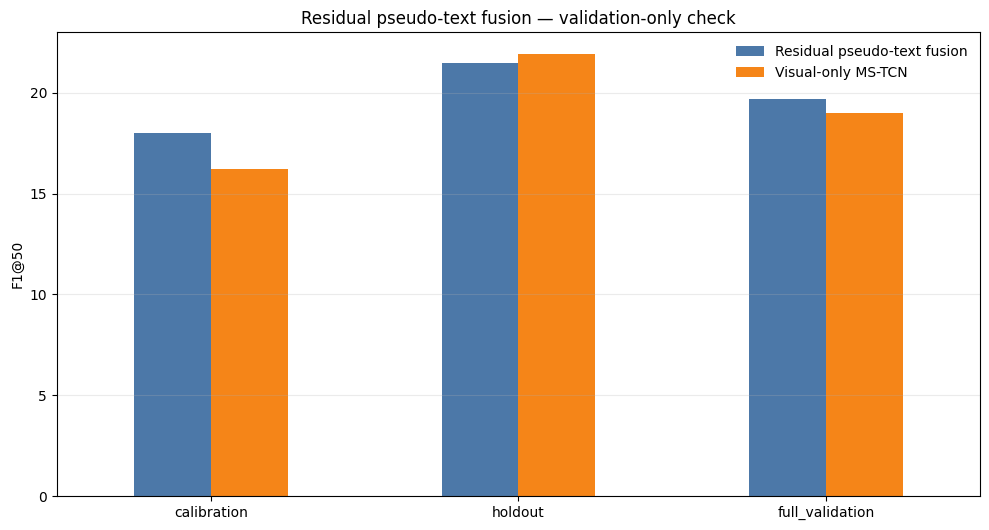

Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/28_residual_pseudotext_logit_fusion/validation_comparison.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/28_residual_pseudotext_logit_fusion/validation_decision.json
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/28_residual_pseudotext_logit_fusion/presentation_artifacts/residual_fusion_validation_table.md
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/28_residual_pseudotext_logit_fusion/presentation_artifacts/residual_fusion_f1_at_50.png
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/28_residual_pseudotext_logit_fusion/fin

In [21]:
comparison_path = OUT_ROOT / "validation_comparison.csv"
decision_path = OUT_ROOT / "validation_decision.json"
summary_path = OUT_ROOT / "final_summary.json"
table_path = ARTIFACT_ROOT / "residual_fusion_validation_table.md"
figure_path = ARTIFACT_ROOT / "residual_fusion_f1_at_50.png"

comparison_df.to_csv(comparison_path, index=False)
decision_path.write_text(json.dumps(decision, indent=2), encoding="utf-8")

for index, sequence_id in enumerate(val_ids):
    prediction_labels = [
        id_to_label[int(class_id)] for class_id in selected_predictions[index]
    ]
    (PREDICTION_ROOT / f"{sequence_id}.txt").write_text(
        "\n".join(prediction_labels) + "\n",
        encoding="utf-8",
    )

presentation_table = comparison_df[
    ["split", "method", "acc", "edit", "f1@10", "f1@25", "f1@50", "f1@50_gain_vs_visual"]
].copy()
for column in ["acc", "edit", "f1@10", "f1@25", "f1@50", "f1@50_gain_vs_visual"]:
    presentation_table[column] = presentation_table[column].map(lambda value: f"{value:.2f}")
table_path.write_text(presentation_table.to_markdown(index=False), encoding="utf-8")

plot_df = comparison_df.pivot(index="split", columns="method", values="f1@50").loc[
    ["calibration", "holdout", "full_validation"]
]
ax = plot_df.plot(kind="bar", figsize=(10, 5.4), color=["#4C78A8", "#F58518"])
ax.set_ylabel("F1@50")
ax.set_xlabel("")
ax.set_title("Residual pseudo-text fusion — validation-only check")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

final_summary = {
    "status": "completed",
    "task": "Assembly101 residual pseudo-text logit fusion",
    "method": (
        "visual log-probability plus a confidence-gated, visual-top-k-restricted "
        "difference between caption-text and zero-text teacher log-probabilities"
    ),
    "primary_metric": "F1@50",
    "data": {
        "split": "validation",
        "num_sequences": len(val_ids),
        "calibration_sequences": len(calibration_indices),
        "holdout_sequences": len(holdout_indices),
        "test_accessed": False,
    },
    "sources": {
        "visual_checkpoint": str(VISUAL_CHECKPOINT),
        "teacher_checkpoint": str(TEACHER_CHECKPOINT),
        "caption_embeddings": str(CAPTION_INPUT_ROOT),
        "qwen_model_id": notebook26_summary.get("source", {}).get("qwen_model_id"),
    },
    "baseline_reproduction": {
        "tolerance": BASELINE_REPRO_TOLERANCE,
        "metrics": rounded_metrics(visual_metrics),
        "absolute_differences": reproduction_differences,
        "passed": True,
    },
    "search": {
        "num_candidates": len(search_df),
        "selection_split": "calibration",
        "holdout_used_for_selection": False,
        "near_best_f1_window": NEAR_BEST_CALIBRATION_F1,
        "search_results": str(search_path),
    },
    "metrics": {
        "visual_only": {
            split: rounded_metrics(metrics) for split, metrics in baseline_by_split.items()
        },
        "selected_fusion": {
            split: rounded_metrics(metrics) for split, metrics in selected_by_split.items()
        },
    },
    "decision": decision,
    "next_step": (
        "Generate pseudo-text for the test split with the frozen notebook-24 prompt, "
        "freeze this fusion configuration, and evaluate test exactly once."
        if promote_to_test
        else "Keep visual-only as the deployable result and report this as a controlled negative follow-up."
    ),
    "artifacts": {
        "comparison_csv": str(comparison_path),
        "decision_json": str(decision_path),
        "selected_predictions": str(PREDICTION_ROOT),
        "presentation_table": str(table_path),
        "f1_at_50_figure": str(figure_path),
    },
    "created_utc": datetime.now(timezone.utc).isoformat(),
}
summary_path.write_text(json.dumps(final_summary, indent=2), encoding="utf-8")

print("Saved:", comparison_path)
print("Saved:", decision_path)
print("Saved:", table_path)
print("Saved:", figure_path)
print("Saved:", summary_path)